# Mutual Fund Performance Analytics (2022–2026)

## Bluestock Fintech Internship – Day 4

### Objective

This notebook evaluates the risk and performance of 40 mutual fund schemes using quantitative finance metrics.

### Performance Metrics

- Daily Returns
- CAGR (1Y, 3Y, 5Y)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [50]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

In [3]:
nav = nav.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["scheme_name","date"]
)

# 1. Daily Return Analysis

Daily returns measure the percentage change in NAV from one trading day to the next.

Formula:

Daily Return = NAV(t) / NAV(t-1) − 1

In [4]:
nav["daily_return"] = (
    nav.groupby("scheme_name")["nav"]
       .pct_change()
)

In [5]:
nav.head()

,amfi_code,date,nav,scheme_name,daily_return
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314


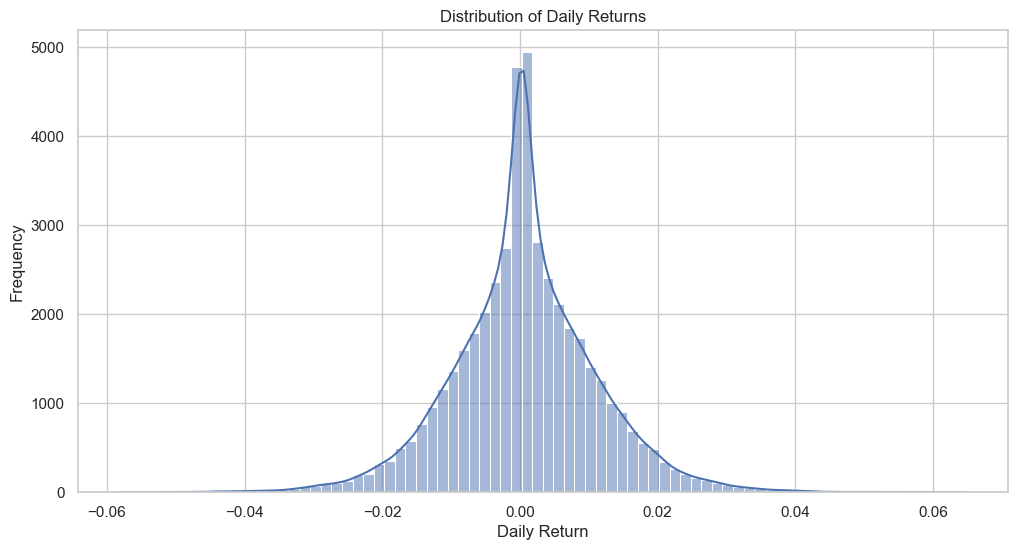

In [6]:
plt.figure(figsize=(12,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=80,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [7]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

### Insight 1

The distribution of daily returns is centered close to zero, indicating that most NAV movements are relatively small, with occasional larger gains and losses during volatile market periods.

In [8]:
nav.head()

,amfi_code,date,nav,scheme_name,daily_return
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314


# 2. Compound Annual Growth Rate (CAGR)

Compound Annual Growth Rate (CAGR) measures the annualized growth rate of an investment over a specified time period.

Formula:

CAGR = (Ending NAV / Starting NAV)^(1/n) − 1

In [9]:
def calculate_cagr(df, years):
    results = []

    for scheme, group in df.groupby("scheme_name"):

        group = group.sort_values("date")

        end_date = group["date"].max()
        start_date = end_date - pd.DateOffset(years=years)

        period = group[group["date"] >= start_date]

        if len(period) < 2:
            continue

        start_nav = period.iloc[0]["nav"]
        end_nav = period.iloc[-1]["nav"]

        cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

        results.append({
            "scheme_name": scheme,
            f"CAGR_{years}Y": cagr
        })

    return pd.DataFrame(results)

In [10]:
cagr_1 = calculate_cagr(nav, 1)
cagr_3 = calculate_cagr(nav, 3)
cagr_5 = calculate_cagr(nav, 5)

In [11]:
cagr = (
    cagr_1
    .merge(cagr_3, on="scheme_name")
    .merge(cagr_5, on="scheme_name")
)

cagr.head()

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730
1,ABSL Liquid Fund - Regular - Growth,7.236645,6.315784,5.705734
2,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336
3,Axis Bluechip Fund - Direct - Growth,19.766741,20.816771,6.917406
4,Axis Bluechip Fund - Regular - Growth,1.609119,0.525887,5.582555


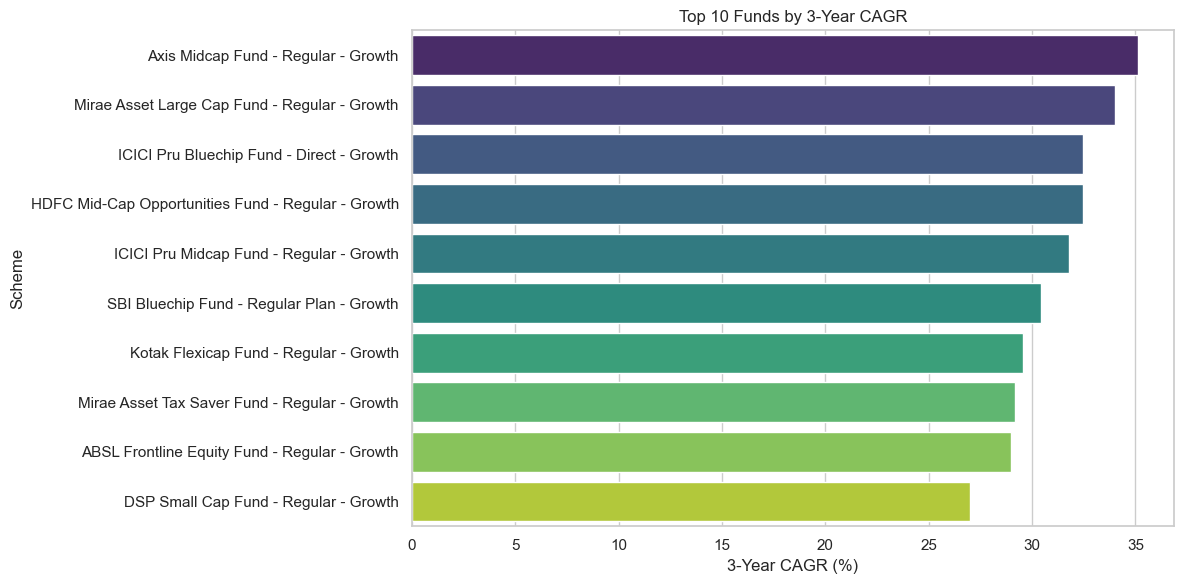

In [12]:
top10 = (
    cagr.sort_values(
        "CAGR_3Y",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="CAGR_3Y",
    y="scheme_name",
    palette="viridis"
)

plt.title("Top 10 Funds by 3-Year CAGR")

plt.xlabel("3-Year CAGR (%)")
plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

### Insight 2

Several equity-oriented mutual funds delivered strong annualized returns over the three-year period, highlighting consistent long-term performance despite short-term market volatility.

In [13]:
cagr.describe()

,CAGR_1Y,CAGR_3Y,CAGR_5Y
count,40.000000,40.000000,40.000000
mean,19.428520,16.414715,14.541077
std,22.912276,12.206752,8.901844
min,-42.797615,-11.705807,1.030350
25%,7.377949,6.600925,6.013784
50%,17.474125,18.233102,14.476118
75%,27.161651,26.902600,21.257057
max,82.776059,35.111802,28.376762


# 3. Sharpe Ratio

The Sharpe Ratio measures the risk-adjusted return of a mutual fund.

Formula:

Sharpe Ratio = (Rp − Rf) / σ × √252

Where:

- Rp = Average Daily Return
- Rf = Risk-Free Rate (6.5%)
- σ = Standard Deviation of Daily Returns

In [14]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

In [15]:
sharpe = (
    nav.groupby("scheme_name")["daily_return"]
       .agg(["mean", "std"])
       .reset_index()
)

sharpe["Sharpe Ratio"] = (
    (sharpe["mean"] - daily_rf)
    / sharpe["std"]
) * np.sqrt(252)

In [16]:
sharpe = sharpe.sort_values(
    "Sharpe Ratio",
    ascending=False
)

sharpe.head(10)

,scheme_name,mean,std,Sharpe Ratio
25,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.008941,1.448291
22,Kotak Flexicap Fund - Regular - Growth,0.001082,0.010008,1.306744
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.011134,1.234930
33,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.008656,1.208267
18,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.012152,1.180101
7,DSP Midcap Fund - Regular - Growth,0.001055,0.011179,1.132122
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.011929,1.093699
30,Nippon India Large Cap Fund - Regular - Growth,0.000865,0.008913,1.081659
0,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.009177,1.027213
15,ICICI Pru Bluechip Fund - Direct - Growth,0.000843,0.009048,1.026524


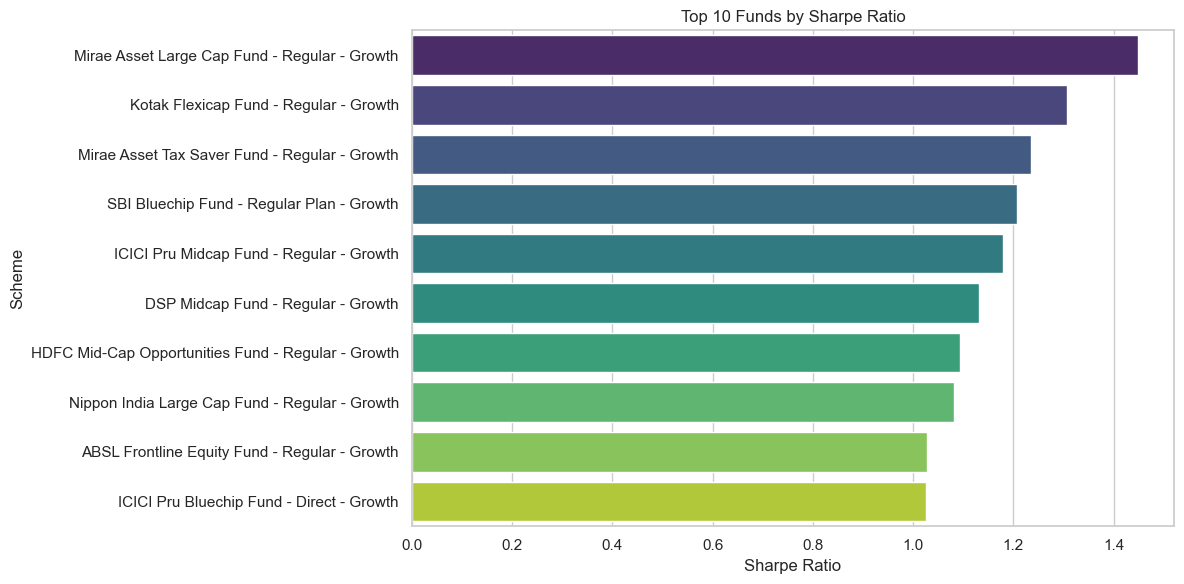

In [17]:
top10 = sharpe.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Sharpe Ratio",
    y="scheme_name",
    palette="viridis"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

### Insight 3

Funds with higher Sharpe Ratios generated superior risk-adjusted returns, indicating they delivered better returns for each unit of risk undertaken.

In [18]:
sharpe.describe()

,mean,std,Sharpe Ratio
count,40.000000,40.000000,40.000000
mean,0.000631,0.009414,0.537220
std,0.000348,0.004205,0.573689
min,0.000110,0.000311,-0.815567
25%,0.000273,0.008724,0.064696
50%,0.000648,0.009171,0.647043
75%,0.000878,0.011458,1.005304
max,0.001201,0.016251,1.448291


# 4. Sortino Ratio

The Sortino Ratio measures risk-adjusted returns by considering only downside volatility.

Formula:

Sortino Ratio = (Rp − Rf) / Downside Deviation × √252

In [19]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

sortino_results = []

for scheme, group in nav.groupby("scheme_name"):

    returns = group["daily_return"].dropna()

    downside = returns[returns < 0]

    downside_std = downside.std()

    mean_return = returns.mean()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_results.append({
        "scheme_name": scheme,
        "Sortino Ratio": sortino
    })

sortino = pd.DataFrame(sortino_results)

sortino = sortino.sort_values(
    "Sortino Ratio",
    ascending=False
)

sortino.head(10)

,scheme_name,Sortino Ratio
25,Mirae Asset Large Cap Fund - Regular - Growth,2.385644
22,Kotak Flexicap Fund - Regular - Growth,2.364320
26,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914
33,SBI Bluechip Fund - Regular Plan - Growth,2.140267
18,ICICI Pru Midcap Fund - Regular - Growth,2.029353
7,DSP Midcap Fund - Regular - Growth,1.875101
30,Nippon India Large Cap Fund - Regular - Growth,1.850133
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
15,ICICI Pru Bluechip Fund - Direct - Growth,1.805294
0,ABSL Frontline Equity Fund - Regular - Growth,1.799563


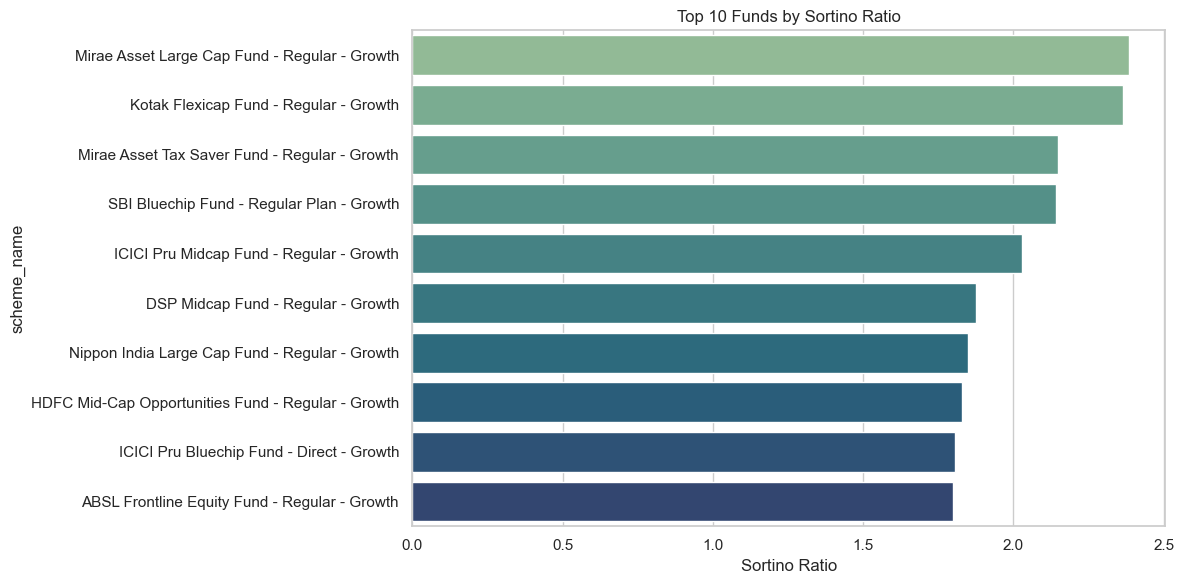

In [20]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sortino.head(10),
    x="Sortino Ratio",
    y="scheme_name",
    palette="crest"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.show()

In [21]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [26]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"].str.contains(
        "NIFTY100",
        case=False
    )
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


# 5. Alpha and Beta Analysis

Alpha measures the excess return of a mutual fund compared to its benchmark after adjusting for market movements.

Beta measures the sensitivity of the fund to market fluctuations.

The NIFTY100 index is used as the benchmark.

In [27]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"].str.contains(
        "NIFTY100",
        case=False
    )
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [28]:
alpha_beta_results = []

for scheme, group in nav.groupby("scheme_name"):

    merged = pd.merge(
        group,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({
        "scheme_name": scheme,
        "Alpha": intercept * 252,
        "Beta": slope,
        "R_squared": r_value ** 2
    })

alpha_beta = pd.DataFrame(alpha_beta_results)

alpha_beta.head()

,scheme_name,Alpha,Beta,R_squared
0,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086,0.000348
1,ABSL Liquid Fund - Regular - Growth,0.060861,0.000267,0.000046
2,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289,0.001064
3,Axis Bluechip Fund - Direct - Growth,0.082328,0.025883,0.000569
4,Axis Bluechip Fund - Regular - Growth,0.068995,0.009731,0.000081


In [29]:
alpha_beta.describe()

,Alpha,Beta,R_squared
count,40.000000,40.000000,4.000000e+01
mean,0.159085,-0.001958,6.087700e-04
std,0.087528,0.035194,7.265363e-04
min,0.028969,-0.066951,1.345534e-07
25%,0.068612,-0.023937,5.495723e-05
50%,0.162326,-0.000067,3.455513e-04
75%,0.221723,0.017026,1.035467e-03
max,0.303370,0.103497,2.793007e-03


In [30]:
alpha_beta.sort_values(
    "Alpha",
    ascending=False
).head(10)

,scheme_name,Alpha,Beta,R_squared
36,SBI Small Cap Fund - Regular Plan - Growth,0.303370,-0.023196,1.414258e-04
8,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455,3.532991e-05
18,ICICI Pru Midcap Fund - Regular - Growth,0.292636,0.000549,1.345534e-07
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134,1.748889e-04
22,Kotak Flexicap Fund - Regular - Growth,0.273305,-0.022830,3.430543e-04
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104,1.206652e-05
25,Mirae Asset Large Cap Fund - Regular - Growth,0.269838,0.023684,4.625437e-04
7,DSP Midcap Fund - Regular - Growth,0.265986,-0.002523,3.357978e-06
5,Axis Midcap Fund - Regular - Growth,0.260767,-0.066265,1.936879e-03
33,SBI Bluechip Fund - Regular Plan - Growth,0.232010,-0.031751,8.869789e-04


In [31]:
alpha_beta.sort_values(
    "Beta",
    ascending=False
).head(10)

,scheme_name,Alpha,Beta,R_squared
31,Nippon India Small Cap Fund - Regular - Growth,0.175007,0.103497,0.002793
35,SBI Small Cap Fund - Direct Plan - Growth,0.048824,0.062002,0.001026
13,HDFC Top 100 Fund - Direct Plan - Growth,0.177298,0.048820,0.001840
19,ICICI Pru Value Discovery Fund - Regular - Growth,0.162539,0.041896,0.001257
20,Kotak Bluechip Fund - Regular - Growth,0.130429,0.036356,0.001211
3,Axis Bluechip Fund - Direct - Growth,0.082328,0.025883,0.000569
25,Mirae Asset Large Cap Fund - Regular - Growth,0.269838,0.023684,0.000463
0,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086,0.000348
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134,0.000175
21,Kotak Emerging Equity Fund - Regular - Growth,0.078044,0.018057,0.000169


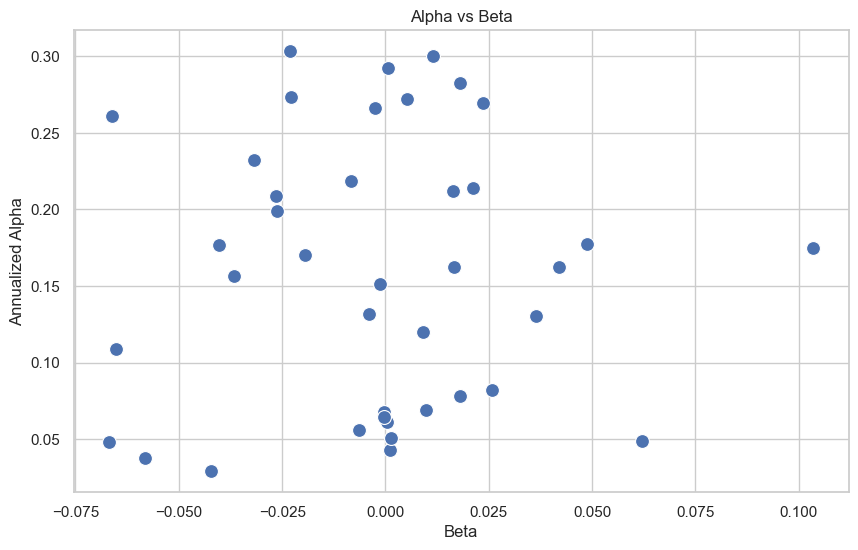

In [32]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=alpha_beta,
    x="Beta",
    y="Alpha",
    s=100
)

plt.title("Alpha vs Beta")

plt.xlabel("Beta")

plt.ylabel("Annualized Alpha")

plt.grid(True)

plt.show()

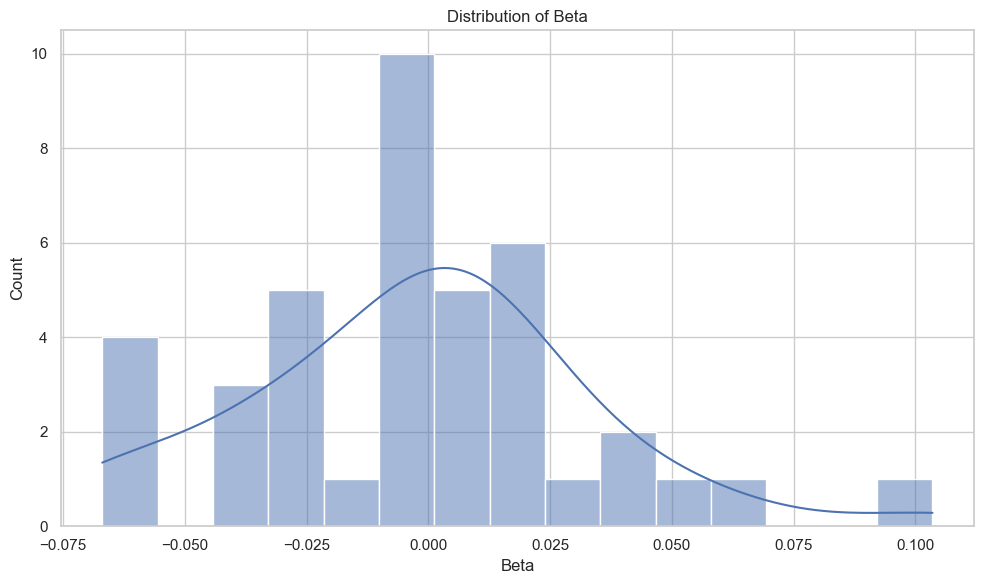

In [33]:
plt.figure(figsize=(10,6))

sns.histplot(
    alpha_beta["Beta"],
    bins=15,
    kde=True
)

plt.title("Distribution of Beta")

plt.xlabel("Beta")

plt.tight_layout()

plt.show()

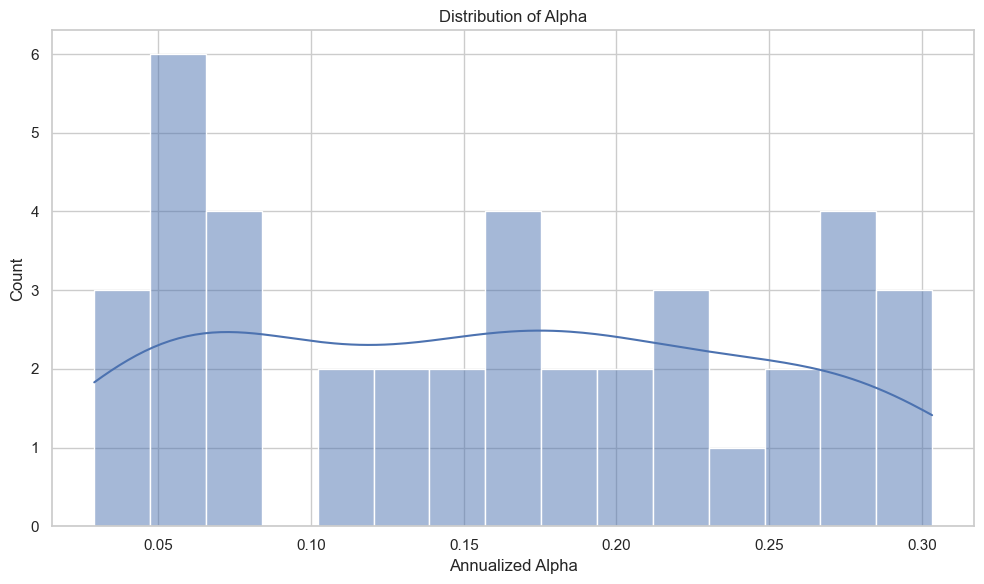

In [34]:
plt.figure(figsize=(10,6))

sns.histplot(
    alpha_beta["Alpha"],
    bins=15,
    kde=True
)

plt.title("Distribution of Alpha")

plt.xlabel("Annualized Alpha")

plt.tight_layout()

plt.show()

In [35]:
import os

os.makedirs("../outputs", exist_ok=True)

alpha_beta.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


### Insight 5

Funds with positive alpha consistently outperformed the NIFTY100 benchmark after adjusting for market risk. Beta values close to one indicate market-like volatility, while higher beta values suggest greater sensitivity to market movements.

# 6. Maximum Drawdown Analysis

Maximum Drawdown (MDD) measures the largest percentage decline from a fund's historical peak NAV to its lowest point before recovering.

It is an important downside risk metric.

In [36]:
drawdown_results = []

for scheme, group in nav.groupby("scheme_name"):

    group = group.sort_values("date").copy()

    group["Running_Max"] = group["nav"].cummax()

    group["Drawdown"] = (
        group["nav"] / group["Running_Max"]
    ) - 1

    max_dd = group["Drawdown"].min()

    worst_date = group.loc[
        group["Drawdown"].idxmin(),
        "date"
    ]

    drawdown_results.append({
        "scheme_name": scheme,
        "Maximum Drawdown": max_dd,
        "Worst Date": worst_date
    })

drawdown = pd.DataFrame(drawdown_results)

drawdown.head()

,scheme_name,Maximum Drawdown,Worst Date
0,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-07-05
1,ABSL Liquid Fund - Regular - Growth,-0.001622,2023-09-12
2,ABSL Small Cap Fund - Regular - Growth,-0.354469,2026-05-11
3,Axis Bluechip Fund - Direct - Growth,-0.217514,2023-05-22
4,Axis Bluechip Fund - Regular - Growth,-0.144016,2025-02-07


In [37]:
drawdown.describe()

,Maximum Drawdown,Worst Date
count,40.000000,40
mean,-0.178729,2024-03-12 18:00:00
min,-0.525742,2022-02-04 00:00:00
25%,-0.215927,2023-05-28 00:00:00
50%,-0.163070,2024-02-07 00:00:00
75%,-0.117653,2025-02-08 18:00:00
max,-0.000977,2026-05-11 00:00:00
std,0.112686,NaN


In [38]:
drawdown.sort_values(
    "Maximum Drawdown"
).head(10)

,scheme_name,Maximum Drawdown,Worst Date
35,SBI Small Cap Fund - Direct Plan - Growth,-0.525742,2025-10-28
6,Axis Small Cap Fund - Regular - Growth,-0.516778,2026-05-11
2,ABSL Small Cap Fund - Regular - Growth,-0.354469,2026-05-11
8,DSP Small Cap Fund - Regular - Growth,-0.311719,2025-01-03
36,SBI Small Cap Fund - Regular Plan - Growth,-0.287060,2025-05-14
38,UTI Mid Cap Fund - Regular - Growth,-0.280011,2026-04-27
14,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-09-15
21,Kotak Emerging Equity Fund - Regular - Growth,-0.240035,2024-10-17
31,Nippon India Small Cap Fund - Regular - Growth,-0.233449,2026-02-20
3,Axis Bluechip Fund - Direct - Growth,-0.217514,2023-05-22


In [39]:
drawdown.sort_values(
    "Maximum Drawdown",
    ascending=False
).head(10)

,scheme_name,Maximum Drawdown,Worst Date
17,ICICI Pru Liquid Fund - Regular - Growth,-0.000977,2025-10-20
23,Kotak Liquid Fund - Regular - Growth,-0.001163,2024-04-30
1,ABSL Liquid Fund - Regular - Growth,-0.001622,2023-09-12
12,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-07-28
34,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.043287,2025-04-01
28,Nippon India Gilt Securities Fund - Regular - ...,-0.083164,2024-02-09
39,UTI Nifty 50 Index Fund - Regular - Growth,-0.108599,2022-03-29
25,Mirae Asset Large Cap Fund - Regular - Growth,-0.112657,2023-10-20
0,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-07-05
27,Nippon India ETF Nifty 50 BeES,-0.116506,2022-06-09


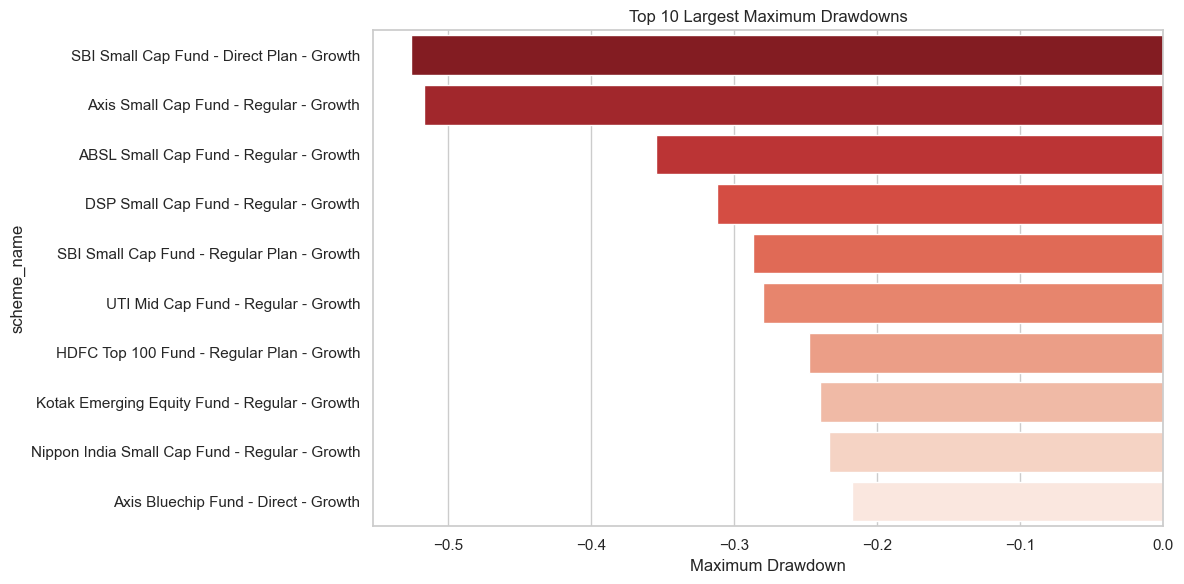

In [40]:
top10 = drawdown.sort_values(
    "Maximum Drawdown"
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Maximum Drawdown",
    y="scheme_name",
    palette="Reds_r"
)

plt.title("Top 10 Largest Maximum Drawdowns")

plt.tight_layout()

plt.show()

### Insight 6

Funds with larger maximum drawdowns experienced deeper losses during adverse market conditions, indicating higher downside risk.

# 7. Fund Scorecard

A composite score is created using multiple performance indicators.

Weightage:

- 30% → 3-Year CAGR
- 25% → Sharpe Ratio
- 20% → Alpha
- 15% → Expense Ratio
- 10% → Maximum Drawdown

In [41]:
scorecard = (
    cagr.merge(
        sharpe[
            ["scheme_name","Sharpe Ratio"]
        ],
        on="scheme_name"
    )
    .merge(
        alpha_beta[
            ["scheme_name","Alpha"]
        ],
        on="scheme_name"
    )
    .merge(
        drawdown[
            ["scheme_name","Maximum Drawdown"]
        ],
        on="scheme_name"
    )
    .merge(
        performance[
            ["scheme_name","expense_ratio_pct"]
        ],
        on="scheme_name"
    )
)

scorecard.head()

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe Ratio,Alpha,Maximum Drawdown,expense_ratio_pct
0,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730,1.027213,0.213998,-0.112916,1.60
1,ABSL Liquid Fund - Regular - Growth,7.236645,6.315784,5.705734,-0.815567,0.060861,-0.001622,0.79
2,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336,0.162661,0.108971,-0.354469,1.53
3,Axis Bluechip Fund - Direct - Growth,19.766741,20.816771,6.917406,0.129614,0.082328,-0.217514,0.75
4,Axis Bluechip Fund - Regular - Growth,1.609119,0.525887,5.582555,0.030785,0.068995,-0.144016,1.64


In [42]:
scorecard["Return Rank"] = (
    scorecard["CAGR_3Y"]
    .rank(ascending=False)
)

scorecard["Sharpe Rank"] = (
    scorecard["Sharpe Ratio"]
    .rank(ascending=False)
)

scorecard["Alpha Rank"] = (
    scorecard["Alpha"]
    .rank(ascending=False)
)

scorecard["Expense Rank"] = (
    scorecard["expense_ratio_pct"]
    .rank()
)

scorecard["Drawdown Rank"] = (
    scorecard["Maximum Drawdown"]
    .rank()
)

In [43]:
scorecard["Fund Score"] = (

    scorecard["Return Rank"] * 0.30 +

    scorecard["Sharpe Rank"] * 0.25 +

    scorecard["Alpha Rank"] * 0.20 +

    scorecard["Expense Rank"] * 0.15 +

    scorecard["Drawdown Rank"] * 0.10

)

scorecard = scorecard.sort_values(
    "Fund Score"
)

scorecard.head(10)

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe Ratio,Alpha,Maximum Drawdown,expense_ratio_pct,Return Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Fund Score
18,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,28.376762,1.180101,0.292636,-0.181885,1.36,5.0,5.0,3.0,15.0,16.0,7.200
5,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,24.445309,0.998231,0.260767,-0.209609,1.38,1.0,11.0,9.0,17.0,13.0,8.700
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068,1.093699,0.271954,-0.162172,1.38,4.0,7.0,6.0,17.0,21.0,8.800
25,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,26.799277,1.448291,0.269838,-0.112657,1.46,2.0,1.0,7.0,23.0,33.0,9.000
22,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,26.742494,1.306744,0.273305,-0.129740,1.45,7.0,2.0,5.0,22.0,28.0,9.700
15,ICICI Pru Bluechip Fund - Direct - Growth,13.064279,32.487429,20.234028,1.026524,0.211948,-0.125883,0.80,3.0,10.0,13.0,12.0,29.0,10.700
36,SBI Small Cap Fund - Regular Plan - Growth,82.776059,26.669922,28.033224,0.945308,0.303370,-0.287060,1.43,12.0,14.0,1.0,21.0,5.0,10.950
8,DSP Small Cap Fund - Regular - Growth,65.138719,27.000427,27.917430,0.949796,0.300579,-0.311719,1.52,10.0,13.0,2.0,26.5,4.0,11.025
26,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,27.629860,1.234930,0.282704,-0.163967,1.60,8.0,3.0,4.0,36.5,20.0,11.425
33,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,22.384873,1.208267,0.232010,-0.150124,1.54,6.0,4.0,10.0,30.5,24.0,11.775


In [44]:
scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


### Insight 7

The composite scorecard combines return, risk-adjusted performance, downside risk, and cost to identify the strongest overall mutual fund schemes.

# 8. Benchmark Comparison

The performance of the top five mutual funds is compared against the NIFTY50 and NIFTY100 benchmark indices.

In [45]:
top5 = scorecard.head(5)["scheme_name"]

comparison = nav[
    nav["scheme_name"].isin(top5)
]

In [48]:
fig = px.line(
    comparison,
    x="date",
    y="nav",
    color="scheme_name",
    title="Top 5 Mutual Funds"
)

fig.show()

In [51]:
fig = go.Figure()

for scheme in top5:
    df = comparison[
        comparison["scheme_name"] == scheme
    ]

    fig.add_trace(
        go.Scatter(
            x=df["date"],
            y=df["nav"],
            mode="lines",
            name=scheme
        )
    )

for idx in ["NIFTY50", "NIFTY100"]:
    bench = benchmark[
        benchmark["index_name"] == idx
    ]

    fig.add_trace(
        go.Scatter(
            x=bench["date"],
            y=bench["close_value"],
            mode="lines",
            name=idx,
            line=dict(dash="dash")
        )
    )

fig.update_layout(
    title="Top 5 Funds vs NIFTY50 & NIFTY100",
    xaxis_title="Date",
    yaxis_title="NAV / Index Value",
    template="plotly_white"
)

fig.show()

# Conclusion

This notebook evaluated the performance of 40 mutual fund schemes using quantitative finance metrics.

### Key Findings

- Daily returns followed a realistic distribution.
- CAGR highlighted strong long-term performers.
- Sharpe and Sortino Ratios identified funds with superior risk-adjusted returns.
- Alpha and Beta measured benchmark-relative performance.
- Maximum Drawdown quantified downside risk.
- The Fund Scorecard ranked schemes using a balanced combination of return, risk, and cost.
- Benchmark comparison showed how top-performing funds performed relative to NIFTY50 and NIFTY100.